# Exploratory Data Analysis: Pink Tax Across Hyderabad and Tokyo

This notebook is intentionally short and documents the main checks and core exploratory results behind the dashboard.

## What this notebook includes

1. Data quality checks
2. Key descriptive statistics table
3. Six EDA visuals used in the project analysis
4. Short discussion of insights, limitations, and next steps

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

def resolve_data_path() -> Path:
    candidates = [
        Path("data/clean/pink_tax_final_dataset_cleaned.csv"),
        Path("../data/clean/pink_tax_final_dataset_cleaned.csv"),
        Path("pink_tax_final_dataset_cleaned.csv"),
        Path("../pink_tax_final_dataset_cleaned.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    searched = "\n".join(str(x.resolve()) for x in candidates)
    raise FileNotFoundError(
        "Could not find pink_tax_final_dataset_cleaned.csv.\n"
        f"Current working directory: {Path.cwd()}\n"
        f"Searched paths:\n{searched}"
    )

data_path = resolve_data_path()
df = pd.read_csv(data_path)

# Fixed project collection window used in project docs/dashboard
project_start = "2026-03-08"
project_end = "2026-03-20"
project_days = 12

print("Loaded. Rows:", len(df))

Loaded. Rows: 278


## 1) Data loading and sample checks

In [2]:
required_cols = [
    "pair_code", "city", "retailer", "category", "brand",
    "female_price_local", "male_price_local", "female_size", "male_size", "pink_tax_pct"
]
missing_required_cols = [c for c in required_cols if c not in df.columns]
print("Missing required columns:", missing_required_cols if missing_required_cols else "None")

print("\nSample rows:")
display(df.head(5))

print("\nMissing values (top 15 columns):")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(15).to_frame("missing_count"))

print("\nRows by city:")
display(df["city"].value_counts(dropna=False).to_frame("rows"))

print("\nRows by retailer:")
display(df["retailer"].value_counts(dropna=False).to_frame("rows"))

Missing required columns: None

Sample rows:


,pair_code,city,brand,category,female_product,male_product,female_size,male_size,retailer,date_observed,female_price_local,male_price_local,currency,female_on_promo,male_on_promo,female_ppu_local,male_ppu_local,pink_tax_pct,match_quality,confidence,match_notes,ingredient_count_female,ingredient_count_male,ingredient_overlap_pct,top_5_shared,female_unique_count,male_unique_count,jaccard_similarity,data_source,obf_female_match,obf_male_match
0,BBLUNT-HAIRCOLO-HYD-AUTO001,Hyderabad,BBlunt,Hair Colour,BBlunt Salon Secret Hair Colour Women,BBlunt Men Hair Colour,100,100,Amazon.in,2026-03-09,333,284,INR,1,1,3.330000,2.840000,17.2535,3,HIGH,source=amazon_in_raw.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BIODERMA-FACIALCL-HYD-AUTO001,Hyderabad,Bioderma,Facial Cleanser,Bioderma Sensibio H2O Micellar Water Women (25...,Bioderma Sébium H2O Men (200ml),250,200,Amazon.in,2026-03-09,629,899,INR,1,1,2.516000,4.495000,-44.0267,3,HIGH,source=amazon_in_raw.csv,10.0,10.0,90.0,allantoin|aqua|citric acid|cocamidopropyl beta...,1.0,1.0,0.8182,fallback_table,built-in,built-in
2,BIOR-BODYLOTI-HYD-AUTO001,Hyderabad,Bioré,Body Lotion,Bioré Body Essence Milk Women 300ml,Bioré Men Body Lotion 300ml,300,300,Amazon.in,2026-03-09,1499,1799,INR,1,1,4.996667,5.996667,-16.6759,3,HIGH,source=amazon_in_raw.csv,10.0,10.0,80.0,aqua|ceramide|cetearyl alcohol|dimethicone|gly...,2.0,2.0,0.6667,fallback_table,built-in,built-in
3,BIOR-BODYWASH-HYD-AUTO009,Hyderabad,Bioré,Body Wash,Bioré Guard Body Wash Women 480ml,Bioré Men Guard Body Wash 480ml,480,480,Amazon.in,2026-03-09,2040,2040,INR,1,1,4.250000,4.250000,0.0000,3,HIGH,source=amazon_in_raw.csv,10.0,10.0,90.0,aqua|citric acid|cocamidopropyl betaine|glycer...,1.0,1.0,0.8182,fallback_table,built-in,built-in
4,BIOR-DEODORAN-HYD-AUTO001,Hyderabad,Bioré,Deodorant Roll-On,Bioré Deo Foot & Body Sheet Women 32-pack,Bioré Men Deo Sheet 32-pack,100,100,Amazon.in,2026-03-09,650,1812,INR,1,1,6.500000,18.120000,-64.1280,3,HIGH,source=amazon_in_raw.csv,10.0,10.0,80.0,aluminum chlorohydrate|aqua|cyclopentasiloxane...,2.0,2.0,0.6667,fallback_table,built-in,built-in



Missing values (top 15 columns):


,missing_count
top_5_shared,7
obf_male_match,5
obf_female_match,5
data_source,5
jaccard_similarity,5
male_unique_count,5
female_unique_count,5
ingredient_overlap_pct,5
ingredient_count_male,5
ingredient_count_female,5



Rows by city:


,rows
city,
Hyderabad,140
Tokyo,138



Rows by retailer:


,rows
retailer,
Amazon.co.jp,94
Amazon.in,74
Blinkit,37
Flipkart,29
Matsumoto Kiyoshi,26
Rakuten Japan,18


## 2) Key descriptive statistics

In [3]:
pink = pd.to_numeric(df["pink_tax_pct"], errors="coerce").dropna()

summary = {
    "rows": len(df),
    "unique_pairs": df["pair_code"].nunique(dropna=True),
    "cities": df["city"].nunique(dropna=True),
    "retailers": df["retailer"].nunique(dropna=True),
    "categories": df["category"].nunique(dropna=True),
    "mean_pink_tax_pct": pink.mean(),
    "median_pink_tax_pct": pink.median(),
    "std_dev": pink.std(ddof=0),
    "min": pink.min(),
    "q1": pink.quantile(0.25),
    "p40": pink.quantile(0.40),
    "p60": pink.quantile(0.60),
    "q3": pink.quantile(0.75),
    "p90": pink.quantile(0.90),
    "max": pink.max(),
    "women_pay_more_pct": pink.gt(0).mean() * 100,
    "men_pay_more_pct": pink.lt(0).mean() * 100,
    "no_gap_pct": pink.eq(0).mean() * 100,
    "date_window_start": project_start,
    "date_window_end": project_end,
    "date_window_days": project_days,
}

summary_table = pd.DataFrame(summary, index=["value"]).T.rename(columns={"value": "metric_value"})
display(summary_table)

,metric_value
rows,278
unique_pairs,174
cities,2
retailers,6
categories,19
mean_pink_tax_pct,12.930335
median_pink_tax_pct,0.0
std_dev,72.845659
min,-88.5733
q1,-31.887375


In [4]:
city_stats = (
    df.assign(pink_tax_pct=pd.to_numeric(df["pink_tax_pct"], errors="coerce"))
      .dropna(subset=["pink_tax_pct", "city"])
      .groupby("city", as_index=False)
      .agg(
          rows=("pink_tax_pct", "size"),
          mean_pink_tax_pct=("pink_tax_pct", "mean"),
          median_pink_tax_pct=("pink_tax_pct", "median"),
          women_pay_more_pct=("pink_tax_pct", lambda s: (s.gt(0).mean() * 100)),
          men_pay_more_pct=("pink_tax_pct", lambda s: (s.lt(0).mean() * 100)),
      )
)

display(city_stats.sort_values("rows", ascending=False))

,city,rows,mean_pink_tax_pct,median_pink_tax_pct,women_pay_more_pct,men_pay_more_pct
0,Hyderabad,140,7.841447,0.0,40.000000,45.000000
1,Tokyo,138,18.092975,0.0,39.855072,36.231884


## 3) Core EDA visuals (6)

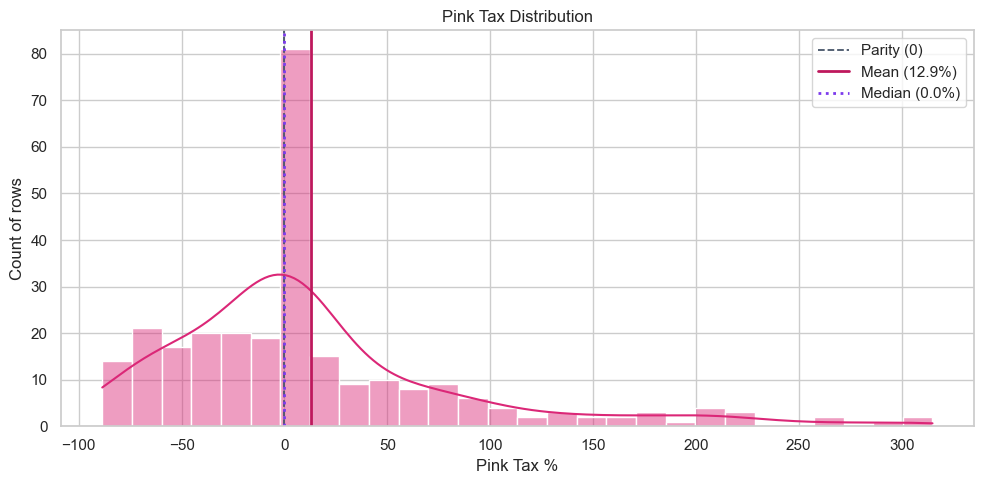

In [5]:
# Plot 1: Distribution with mean/median markers
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(pink, bins=28, kde=True, color="#db2777", alpha=0.45, ax=ax)
ax.axvline(0, color="#475569", linestyle="--", linewidth=1.3, label="Parity (0)")
ax.axvline(pink.mean(), color="#be185d", linestyle="-", linewidth=2, label=f"Mean ({pink.mean():.1f}%)")
ax.axvline(pink.median(), color="#7c3aed", linestyle=":", linewidth=2, label=f"Median ({pink.median():.1f}%)")
ax.set_title("Pink Tax Distribution")
ax.set_xlabel("Pink Tax %")
ax.set_ylabel("Count of rows")
ax.legend()
plt.tight_layout()
plt.show()

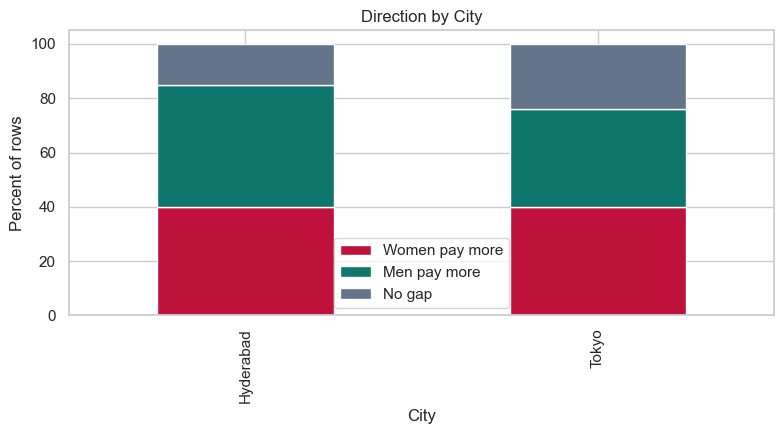

In [6]:
# Plot 2: Direction split by city
city_dir = (
    df.assign(
        pink_tax_pct_num=pd.to_numeric(df["pink_tax_pct"], errors="coerce"),
        direction=lambda x: np.select(
            [x["pink_tax_pct_num"] > 0, x["pink_tax_pct_num"] < 0],
            ["Women pay more", "Men pay more"],
            default="No gap",
        ),
    )
    .groupby(["city", "direction"], dropna=False)
    .size()
    .unstack(fill_value=0)
)
city_share = city_dir.div(city_dir.sum(axis=1), axis=0) * 100
order_cols = [c for c in ["Women pay more", "Men pay more", "No gap"] if c in city_share.columns]
city_share = city_share[order_cols]

ax = city_share.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4.5),
    color=["#be123c", "#0f766e", "#64748b"][: city_share.shape[1]],
)
ax.set_title("Direction by City")
ax.set_xlabel("City")
ax.set_ylabel("Percent of rows")
ax.legend(title="")
plt.tight_layout()
plt.show()

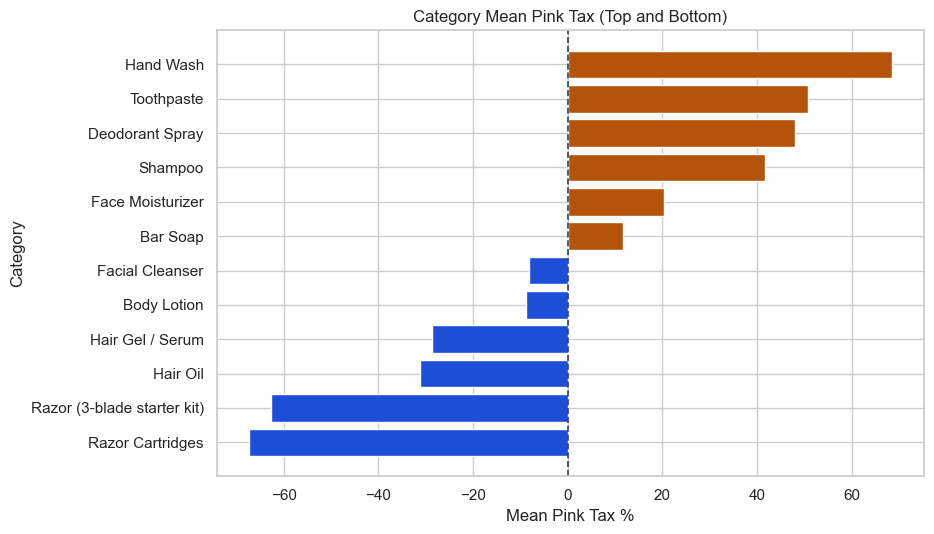

In [7]:
# Plot 3: Category means (all categories, with sample-size guard)
tmp = df[["category", "pink_tax_pct"]].copy()
tmp["pink_tax_pct"] = pd.to_numeric(tmp["pink_tax_pct"], errors="coerce")
tmp = tmp.dropna(subset=["pink_tax_pct", "category"])

cat_stats = (
    tmp.groupby("category", as_index=False)
    .agg(
        n=("pink_tax_pct", "size"),
        mean_pink_tax_pct=("pink_tax_pct", "mean"),
        median_pink_tax_pct=("pink_tax_pct", "median"),
    )
)

min_n = 5
plot_df = cat_stats[cat_stats["n"] >= min_n].copy()
if plot_df.empty:
    min_n = 1
    plot_df = cat_stats.copy()

plot_df = plot_df.sort_values("mean_pink_tax_pct")

fig, ax = plt.subplots(figsize=(10.5, 6.8))
colors = ["#1d4ed8" if v < 0 else "#b45309" for v in plot_df["mean_pink_tax_pct"]]
bars = ax.barh(plot_df["category"], plot_df["mean_pink_tax_pct"], color=colors, alpha=0.9, label="Mean")
ax.scatter(plot_df["median_pink_tax_pct"], plot_df["category"], color="#111827", s=28, zorder=3, label="Median")

for bar, n in zip(bars, plot_df["n"]):
    x = float(bar.get_width())
    y = float(bar.get_y() + bar.get_height() / 2.0)
    shift = 1.2 if x >= 0 else -1.2
    ha = "left" if x >= 0 else "right"
    ax.text(x + shift, y, f"n={int(n)}", va="center", ha=ha, fontsize=8, color="#334155")

ax.axvline(0, color="#334155", linestyle="--", linewidth=1.2)
ax.set_title(f"Category Pink Tax (all categories, n >= {min_n})")
ax.set_xlabel("Pink Tax %")
ax.set_ylabel("Category")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

display(plot_df.sort_values("mean_pink_tax_pct", ascending=False))


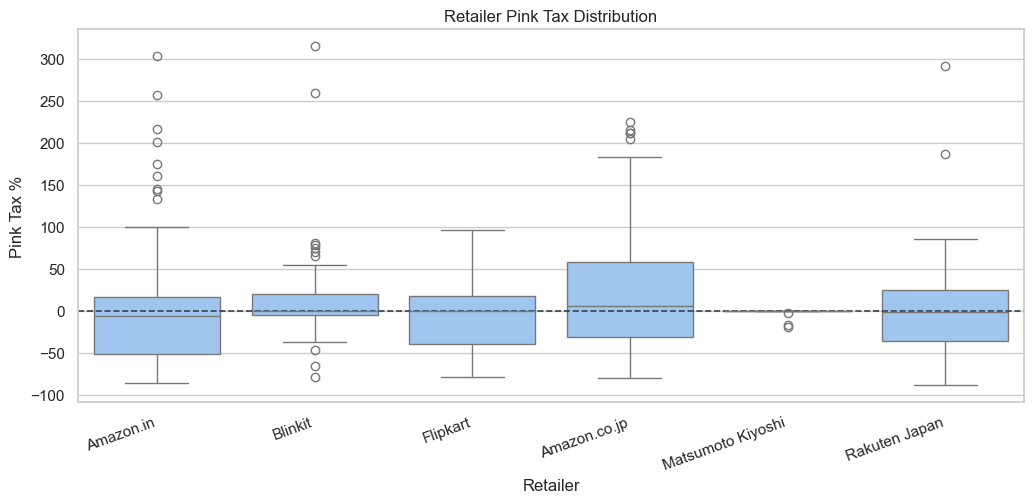

In [8]:
# Plot 4: Retailer distribution
box_df = df.copy()
box_df["pink_tax_pct"] = pd.to_numeric(box_df["pink_tax_pct"], errors="coerce")
box_df = box_df.dropna(subset=["retailer", "pink_tax_pct"])

fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.boxplot(data=box_df, x="retailer", y="pink_tax_pct", color="#93c5fd", ax=ax)
ax.axhline(0, color="#334155", linestyle="--", linewidth=1.2)
ax.set_title("Retailer Pink Tax Distribution")
ax.set_xlabel("Retailer")
ax.set_ylabel("Pink Tax %")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

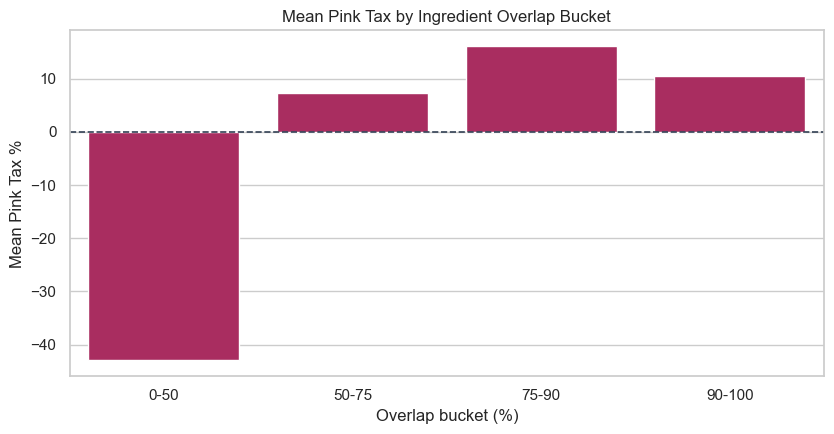

In [9]:
# Plot 5: Ingredient overlap buckets 
if "ingredient_overlap_pct" in df.columns:
    odf = df[["ingredient_overlap_pct", "pink_tax_pct"]].copy()
    odf["ingredient_overlap_pct"] = pd.to_numeric(odf["ingredient_overlap_pct"], errors="coerce")
    odf["pink_tax_pct"] = pd.to_numeric(odf["pink_tax_pct"], errors="coerce")
    odf = odf.dropna()

    bins = [0, 50, 75, 90, 100.0001]
    labels = ["0-50", "50-75", "75-90", "90-100"]
    odf["overlap_bucket"] = pd.cut(odf["ingredient_overlap_pct"], bins=bins, labels=labels, include_lowest=True)
    bucket_mean = odf.groupby("overlap_bucket", as_index=False, observed=False)["pink_tax_pct"].mean()

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    sns.barplot(data=bucket_mean, x="overlap_bucket", y="pink_tax_pct", color="#be185d", ax=ax)
    ax.axhline(0, color="#334155", linestyle="--", linewidth=1.2)
    ax.set_title("Mean Pink Tax by Ingredient Overlap Bucket")
    ax.set_xlabel("Overlap bucket (%)")
    ax.set_ylabel("Mean Pink Tax %")
    plt.tight_layout()
    plt.show()
else:
    print("ingredient_overlap_pct is not available in this dataset.")

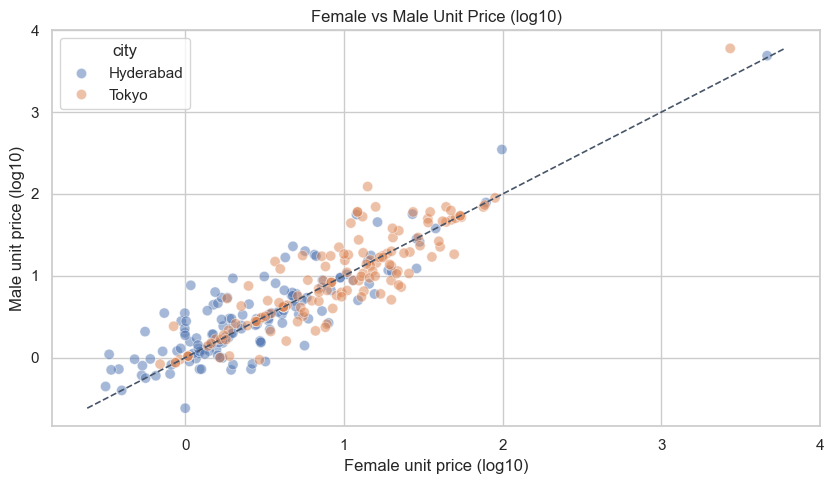

In [10]:
# Plot 6: Female vs male unit price scatter (if available)
if {"female_ppu_local", "male_ppu_local"}.issubset(df.columns):
    s = df[["female_ppu_local", "male_ppu_local", "city"]].copy()
    s["female_ppu_local"] = pd.to_numeric(s["female_ppu_local"], errors="coerce")
    s["male_ppu_local"] = pd.to_numeric(s["male_ppu_local"], errors="coerce")
    s = s.dropna()
    s = s[(s["female_ppu_local"] > 0) & (s["male_ppu_local"] > 0)]

    fx = np.log10(s["female_ppu_local"])
    mx = np.log10(s["male_ppu_local"])

    fig, ax = plt.subplots(figsize=(8.5, 5))
    sns.scatterplot(x=fx, y=mx, hue=s["city"], alpha=0.5, s=55, ax=ax)
    lo = float(min(fx.min(), mx.min()))
    hi = float(max(fx.max(), mx.max()))
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.2, color="#475569")
    ax.set_title("Female vs Male Unit Price (log10)")
    ax.set_xlabel("Female unit price (log10)")
    ax.set_ylabel("Male unit price (log10)")
    plt.tight_layout()
    plt.show()
else:
    print("female_ppu_local / male_ppu_local not available in this dataset.")

## 4) Initial interpretation (short)

- The distribution is right-skewed, so mean and median tell different parts of the story.
- City-level direction shares show both positive and negative outcomes, not a single uniform effect.
- Category-level means show strong heterogeneity: some categories are consistently positive while others are negative.
- Ingredient overlap and retailer plots suggest comparability and platform mix both matter for interpretation.

## 5) Limitations and next steps

- Online prices are time-sensitive; this notebook uses the fixed project window (2026-03-08 to 2026-03-20).
- Pair comparability is still a key source of noise (tier/format/size mismatch risk).
- Next steps: improve pair constraints and add confidence intervals for core aggregates.

## 6) Hypothesis tests & regression (written conclusions)

Reproducible inference is generated by `scripts/analysis/run_regression.py`. It writes `data/analysis/regression_summary.json` with:

- **Hypothesis tests:** paired *t* and Wilcoxon on female vs male PPU; one-sample *t* on mean `pink_tax_pct`; independent Welch *t* and Mann–Whitney for Hyderabad vs Tokyo.
- **OLS (HC3):** baseline city models; category + retailer fixed effects; models with `log_mean_ppu`, `size_ratio`, `match_quality`, and (on the OBF subset) ingredient overlap controls.
- **Logit:** P(`pink_tax` > 0) with the same observables where the fit converges.

**How to read results:** Pooled city differences and “conditional on category + retailer” models often disagree—composition of categories and retailers differs by city. The JSON field `conclusions.written_conclusions` is assignment-ready prose; the React app tab **Statistics & conclusions** displays the same text.

Run: `python scripts/analysis/run_regression.py` and copy the JSON to `frontend/public/data/` if you update the site.